In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading Dataset

In [3]:
df = pd.read_csv('plant_moniter_health_data.csv')
df.head

<bound method NDFrame.head of        Plant_ID  Temperature_C  Humidity_%  Soil_Moisture_%   Soil_pH  \
0       Plant_1      26.490142   73.993554        34.872326  5.546096   
1       Plant_2      24.585207   69.246337        42.832220  6.069807   
2       Plant_3      26.943066   60.596304        33.113701  6.293197   
3       Plant_4      29.569090   53.530632        40.380577  7.443844   
4       Plant_5      24.297540   66.982233        16.595780  6.778277   
..          ...            ...         ...              ...       ...   
995   Plant_996      24.156699   70.701502        46.162208  6.514229   
996   Plant_997      30.393060   59.734787        48.866288  5.461094   
997   Plant_998      26.922529   51.181253        26.373591  6.339851   
998   Plant_999      23.286463   58.369330        50.012646  7.321689   
999  Plant_1000      26.717748   52.550974        42.671114  6.680324   

     Nutrient_Level  Light_Intensity_lux  Health_Score  Health_Status  
0         41.365064  

### EDA

In [4]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Plant_ID             1000 non-null   str    
 1   Temperature_C        1000 non-null   float64
 2   Humidity_%           1000 non-null   float64
 3   Soil_Moisture_%      1000 non-null   float64
 4   Soil_pH              1000 non-null   float64
 5   Nutrient_Level       1000 non-null   float64
 6   Light_Intensity_lux  1000 non-null   float64
 7   Health_Score         1000 non-null   float64
 8   Health_Status        1000 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 70.4 KB
None
Plant_ID               0
Temperature_C          0
Humidity_%             0
Soil_Moisture_%        0
Soil_pH                0
Nutrient_Level         0
Light_Intensity_lux    0
Health_Score           0
Health_Status          0
dtype: int64


C:\Users\anany\AppData\Local\Temp\ipykernel_21252\3140790814.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Health_Status', data=df, palette='viridis')


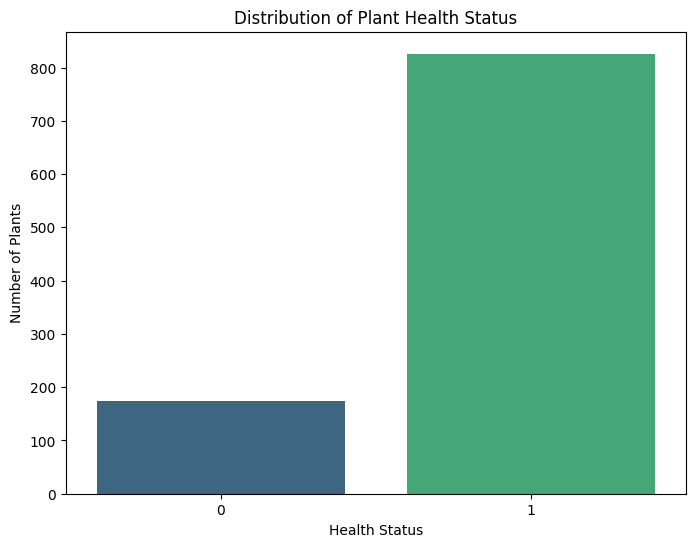

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Health_Status', data=df, palette='viridis')
plt.title('Distribution of Plant Health Status')
plt.xlabel('Health Status')
plt.ylabel('Number of Plants')
plt.show()  

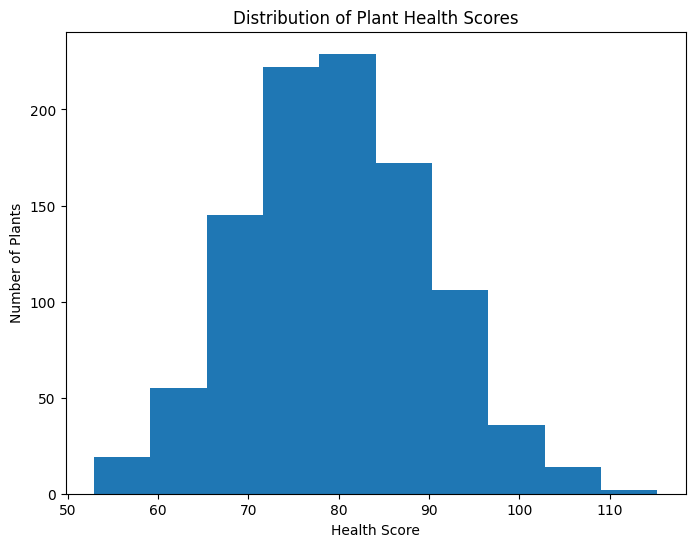

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(x =df['Health_Score'], bins = 10)
plt.title('Distribution of Plant Health Scores')
plt.xlabel('Health Score')
plt.ylabel('Number of Plants')
plt.show()

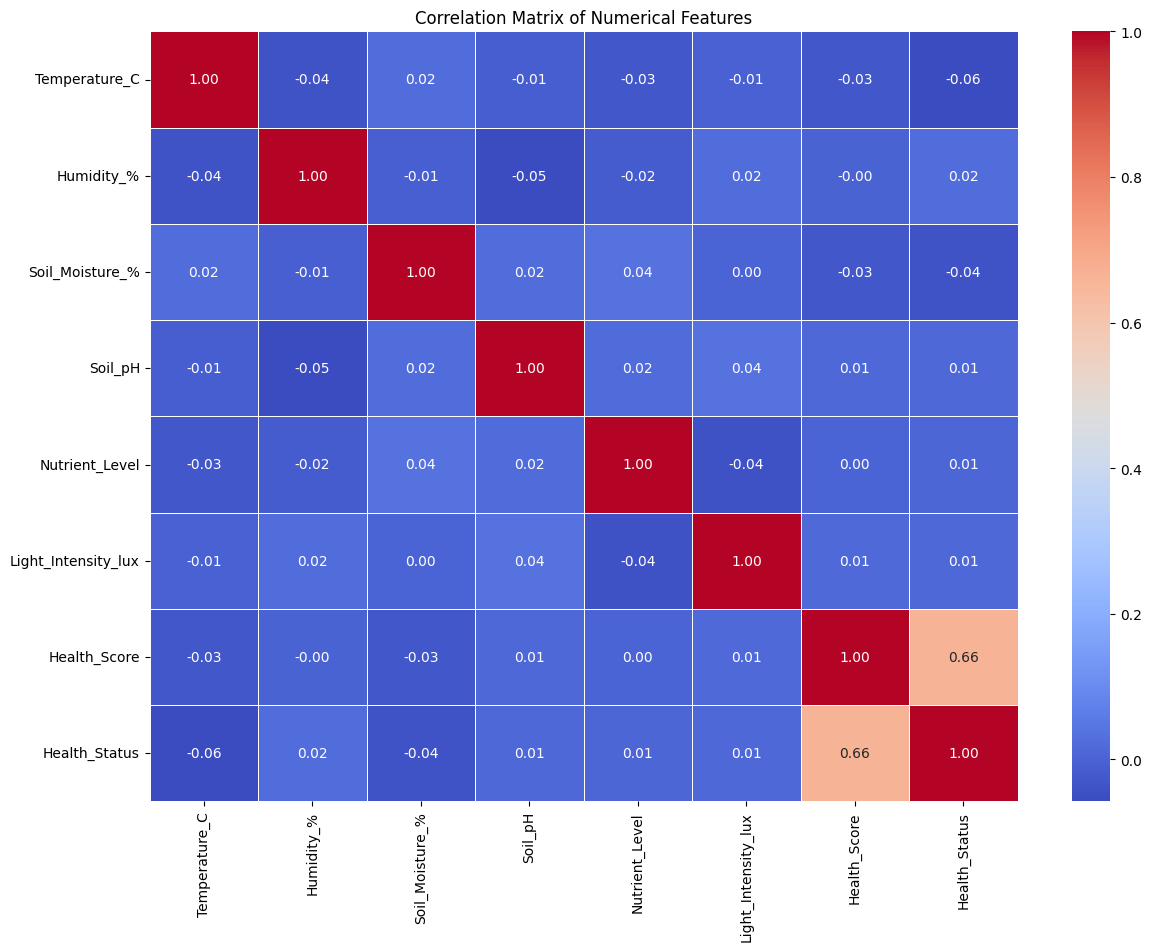

In [16]:
corr_matrix = df[df.columns[1:]].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [17]:
from sklearn.feature_selection import mutual_info_classif

In [23]:
mutual_info = mutual_info_classif(df[df.columns[1:-2]], df[df.columns[-1]])

In [24]:
mutual_info

array([0.        , 0.00194994, 0.        , 0.        , 0.        ,
       0.        ])

In [26]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = df.columns[1:-2]
mutual_info


Temperature_C          0.00000
Humidity_%             0.00195
Soil_Moisture_%        0.00000
Soil_pH                0.00000
Nutrient_Level         0.00000
Light_Intensity_lux    0.00000
dtype: float64

Negligible MI shows that the features have no direct pattern to determine the target

Check if combination of features can determine target

Find if combined features have a signal using random forest classifier

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [77]:
data = dict()
features = []
values = []
health_status = []

for column in df.columns[1:-2]:
    for i in range(len(df[column])):
        features.append(column)
        values.append(df.at[i, column])
        health_status.append(df.at[i, 'Health_Status'])

data['feature']  = features
data['values'] = values
data['health_status'] = health_status

data_df = pd.DataFrame.from_dict(data, orient = 'columns')
data_df

,feature,values,health_status
0,Temperature_C,26.490142,0
1,Temperature_C,24.585207,1
2,Temperature_C,26.943066,1
3,Temperature_C,29.569090,1
4,Temperature_C,24.297540,1
...,...,...,...
5995,Light_Intensity_lux,20514.407953,1
5996,Light_Intensity_lux,23457.944310,1
5997,Light_Intensity_lux,16347.788620,1
5998,Light_Intensity_lux,21403.851266,1


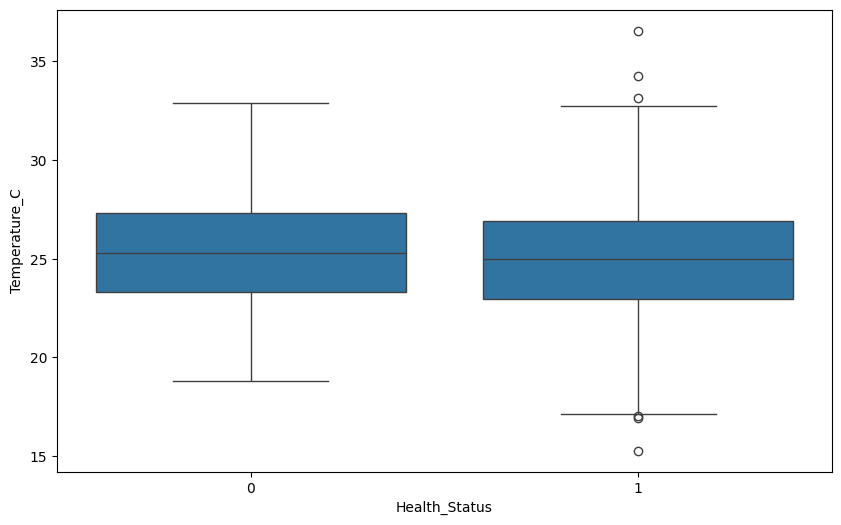

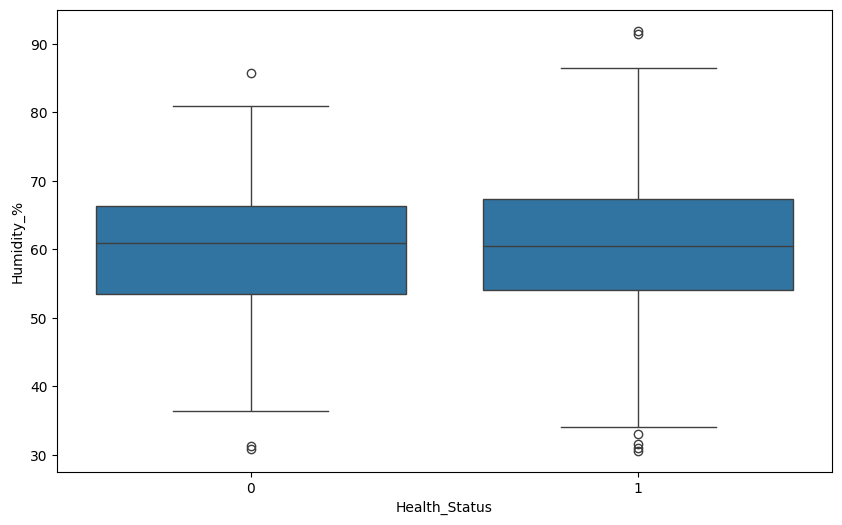

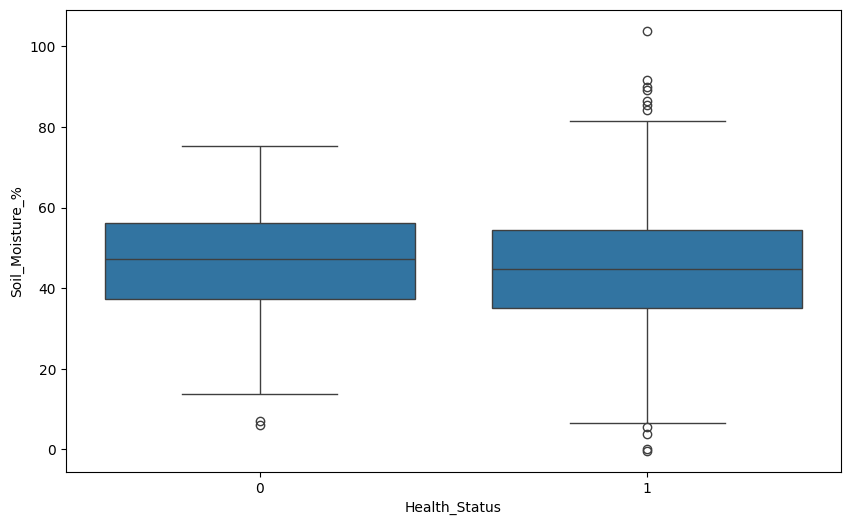

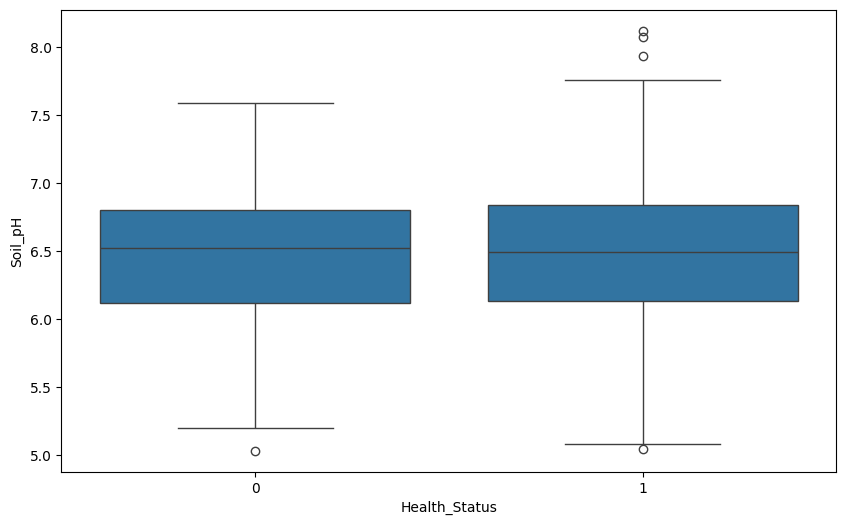

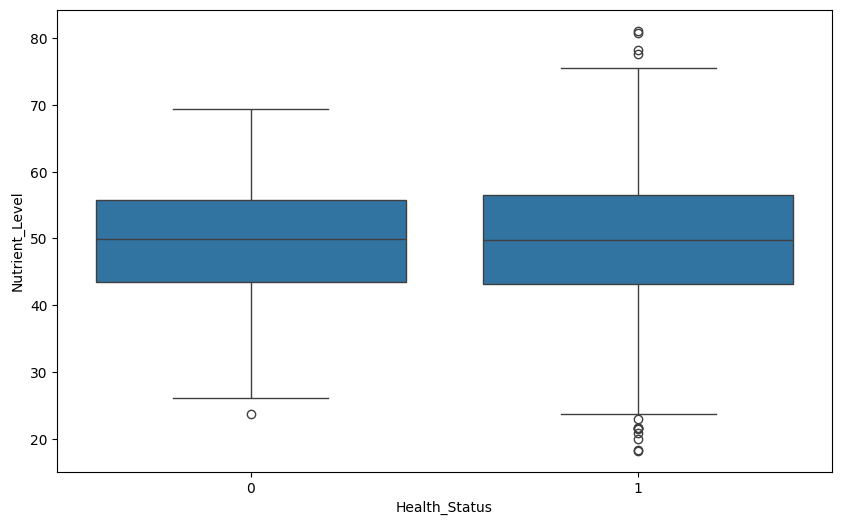

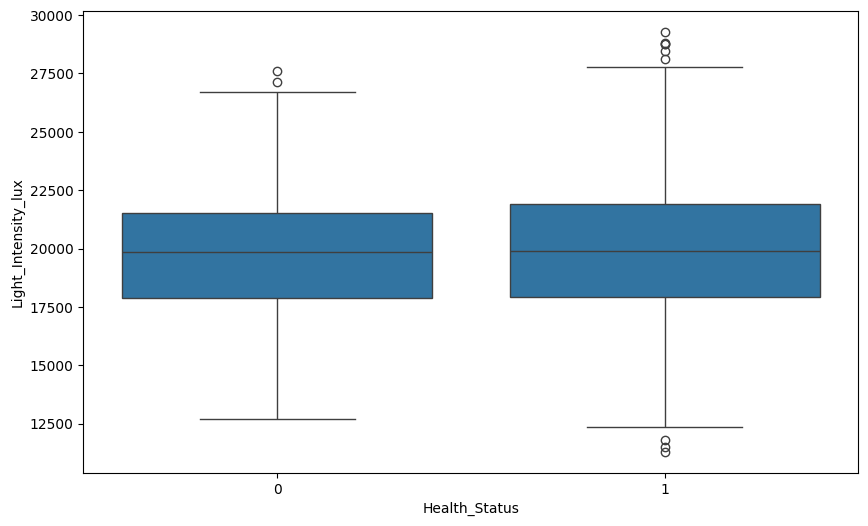

In [98]:
for feature in df.columns[1:-2]:
    plt.figure(figsize=(10,6))
    sns.boxplot(data = df, x = 'Health_Status', y = feature)

In [105]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define features and target
X = df.iloc[:, 1:-2]
y = df['Health_Status']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Accuracy: 0.85


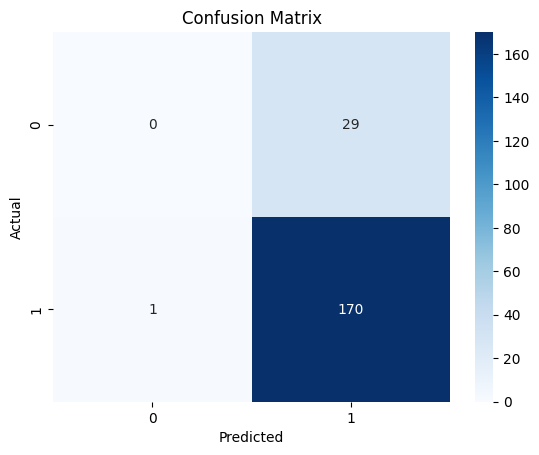

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        29
           1       0.85      0.99      0.92       171

    accuracy                           0.85       200
   macro avg       0.43      0.50      0.46       200
weighted avg       0.73      0.85      0.79       200



In [106]:
# Predict on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Display the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification report
print(classification_report(y_test, y_pred))


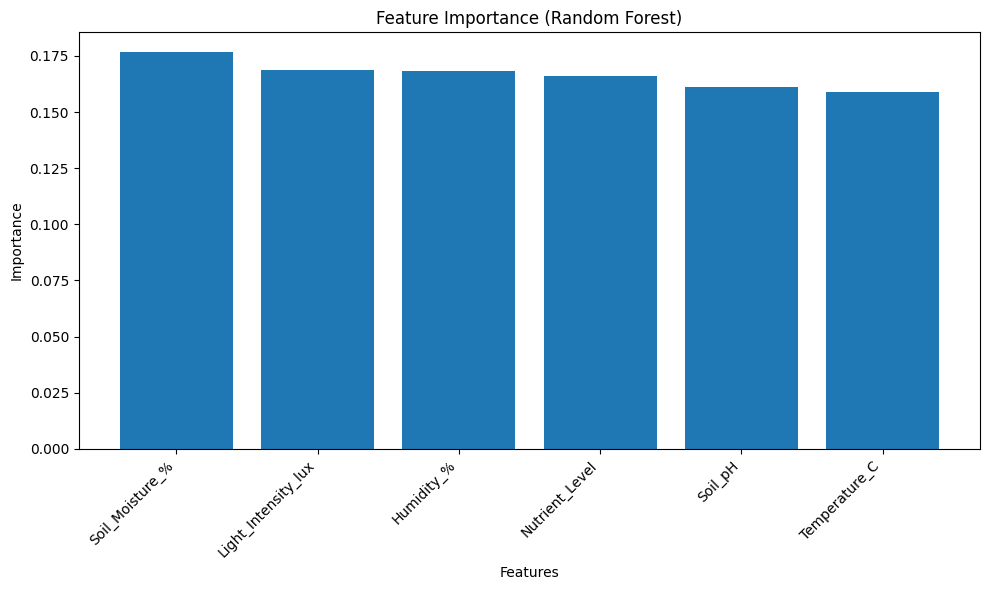

In [107]:
# 3. Get feature importance
importances = model.feature_importances_

# 4. Create DataFrame for plotting
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 5. Plot
plt.figure(figsize=(10, 6))
plt.bar(feat_imp['Feature'], feat_imp['Importance'])
plt.xticks(rotation=45, ha='right')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [108]:
from sklearn.tree import export_text

# Assuming 'rf' is your trained RandomForestClassifier or Regressor
# Iterate through individual trees (e.g., the first 3 trees)
for i in range(1):
    tree_rules = export_text(model.estimators_[i], feature_names=list(X.columns))
    print(f"--- Decision Rules for Tree {i} ---")
    print(tree_rules)


--- Decision Rules for Tree 0 ---
|--- Soil_pH <= 5.22
|   |--- Temperature_C <= 24.68
|   |   |--- Nutrient_Level <= 51.86
|   |   |   |--- class: 1.0
|   |   |--- Nutrient_Level >  51.86
|   |   |   |--- class: 0.0
|   |--- Temperature_C >  24.68
|   |   |--- class: 1.0
|--- Soil_pH >  5.22
|   |--- Temperature_C <= 30.81
|   |   |--- Nutrient_Level <= 65.13
|   |   |   |--- Light_Intensity_lux <= 19420.65
|   |   |   |   |--- Soil_Moisture_% <= 55.33
|   |   |   |   |   |--- Nutrient_Level <= 57.93
|   |   |   |   |   |   |--- Soil_Moisture_% <= 28.21
|   |   |   |   |   |   |   |--- Nutrient_Level <= 49.91
|   |   |   |   |   |   |   |   |--- Light_Intensity_lux <= 15185.85
|   |   |   |   |   |   |   |   |   |--- Light_Intensity_lux <= 14373.57
|   |   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |   |   |--- Light_Intensity_lux >  14373.57
|   |   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |   |--- Light_Intensity_lu

In [109]:
from sklearn.dummy import DummyClassifier

model = DummyClassifier(strategy='most_frequent')

# train
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[  0  29]
 [  0 171]]


In [110]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.85


Final Verdict: Dataset is not usable